In [9]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Tue Jul 15 09:25:31 2025
@author: alex
"""

import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.stats import kruskal
import matplotlib.patches as mpatches
import umap.umap_ as umap

# ignore warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")


In [10]:
# === Paths ===
modality = "QSM"
save_dir = f"bivar_clus_{modality}"
os.makedirs(save_dir, exist_ok=True)

shap_h_path = f"NEW COLUMNS GNC/MD+thickness+QSM_dual_channel/shap_matrix_h_{modality}_mean.csv"
shap_MA_path = f"NEW COLUMNS GNC/MD+thickness+QSM_dual_channel/shap_matrix_MA_{modality}_mean.csv"
meta_path = "../AD_DECODE_data3.xlsx"
pred_results_path1 = 'Compare_Model/QSM+MD+Thickness_subject_level_mean_raw_and_corrected_pred_on_age.csv'
pred_results_path2 = 'Compare_Model/QSM+MD+Thickness_subject_level_mean_raw_and_corrected_pred_on_age_MCIandAD.csv'

# Create merged metadata and prediction results dataframe
pred_results1 = pd.read_csv(pred_results_path1, index_col=0)
pred_results2 = pd.read_csv(pred_results_path2, index_col=0)
results_df = pd.concat([pred_results1, pred_results2])
metadata_df = pd.read_excel(meta_path)
metadata_df = metadata_df.set_index('MRI_Exam')
merged_df = results_df.join(metadata_df, how='inner')
# Create APOE4 column based on genotype column
merged_df['APOE4'] = merged_df['genotype'].apply(lambda x: 1 if '4' in str(x) else 0)
# make setting the index safe: only set if 'subject_id' is a column,
# otherwise assume the dataframe is already indexed by subject id and name the index
if 'subject_id' in merged_df.columns:
    merged_df.set_index('subject_id', inplace=True)
else:
    if merged_df.index.name != 'subject_id':
        merged_df.index.name = 'subject_id'
merged_df.head()

,true_age,pred_age_raw,pred_age_corr,n_preds,pred_sd_raw,pred_sd_corr,bag_raw,bag_sd_raw,bag_corr,bag_sd_corr,...,fluency_4x,letter_fluency,ufov1,ufov2,ufov3,Story_Immediate_verbatim,Story_Immediate_paraphrase,Delayed_verbatim,Delayed_paraphrase,APOE4
subject_id,,,,,,,,,,,,,,,,,,,,,
1470.0,60.66,53.561151,51.634164,10,1.190406,0.972886,-7.098849,1.190406,-9.025836,0.972886,...,14.75,13.0,17.0,120.0,120.0,21.0,1.0,14.0,2.0,0
1912.0,36.00,43.316866,38.255105,10,2.382417,2.521448,7.316866,2.382417,2.255105,2.521448,...,16.75,26.0,17.0,37.0,63.0,33.0,3.0,33.0,3.0,0
2110.0,40.00,47.783199,48.170938,10,2.582670,2.253046,7.783199,2.582670,8.170938,2.253046,...,12.00,18.0,17.0,27.0,60.0,24.0,3.0,23.0,1.0,0
2227.0,37.00,43.251008,38.822331,10,3.345432,2.643740,6.251008,3.345432,1.822331,2.643740,...,15.50,32.0,17.0,30.0,107.0,8.0,0.0,7.0,2.0,0
2363.0,72.00,86.428951,85.450475,10,6.753159,6.972211,14.428951,6.753159,13.450475,6.972211,...,18.25,30.0,17.0,63.0,143.0,21.0,1.0,12.0,0.0,1


In [11]:
# === Load SHAP and Metadata ===
shap_h_df = pd.read_csv(shap_h_path, index_col=0)
shap_MA_df = pd.read_csv(shap_MA_path, index_col=0)
shap_df = pd.concat([shap_h_df, shap_MA_df])
print(f"SHAP DataFrame shape: {shap_df.shape}")

SHAP DataFrame shape: (64, 68)


In [12]:

# Align metadata and SHAP
shap_df = shap_df.loc[shap_df.index.intersection(merged_df.index)]
merged_df = merged_df.loc[shap_df.index]

# === Z-score Normalize and Clip ===
shap_scaled = (shap_df - shap_df.mean()) / shap_df.std()
shap_scaled = shap_scaled.clip(lower=-3, upper=3)


# === Determine Optimal Clusters ===
sil_scores = []
cluster_range = range(2, 11)
for n_clusters in cluster_range:
    #clusterer = AgglomerativeClustering(n_clusters=n_clusters, affinity='euclidean', linkage='ward')
    clusterer = AgglomerativeClustering(n_clusters=n_clusters, metric='euclidean', linkage='ward')

    cluster_labels = clusterer.fit_predict(shap_scaled)
    score = silhouette_score(shap_scaled, cluster_labels)
    sil_scores.append(score)

optimal_clusters = cluster_range[np.argmax(sil_scores)]
print(f"Optimal number of clusters: {optimal_clusters}")



Optimal number of clusters: 2


Manually selected number of clusters: 3
✅ All outputs saved to: bivar_clus_QSM


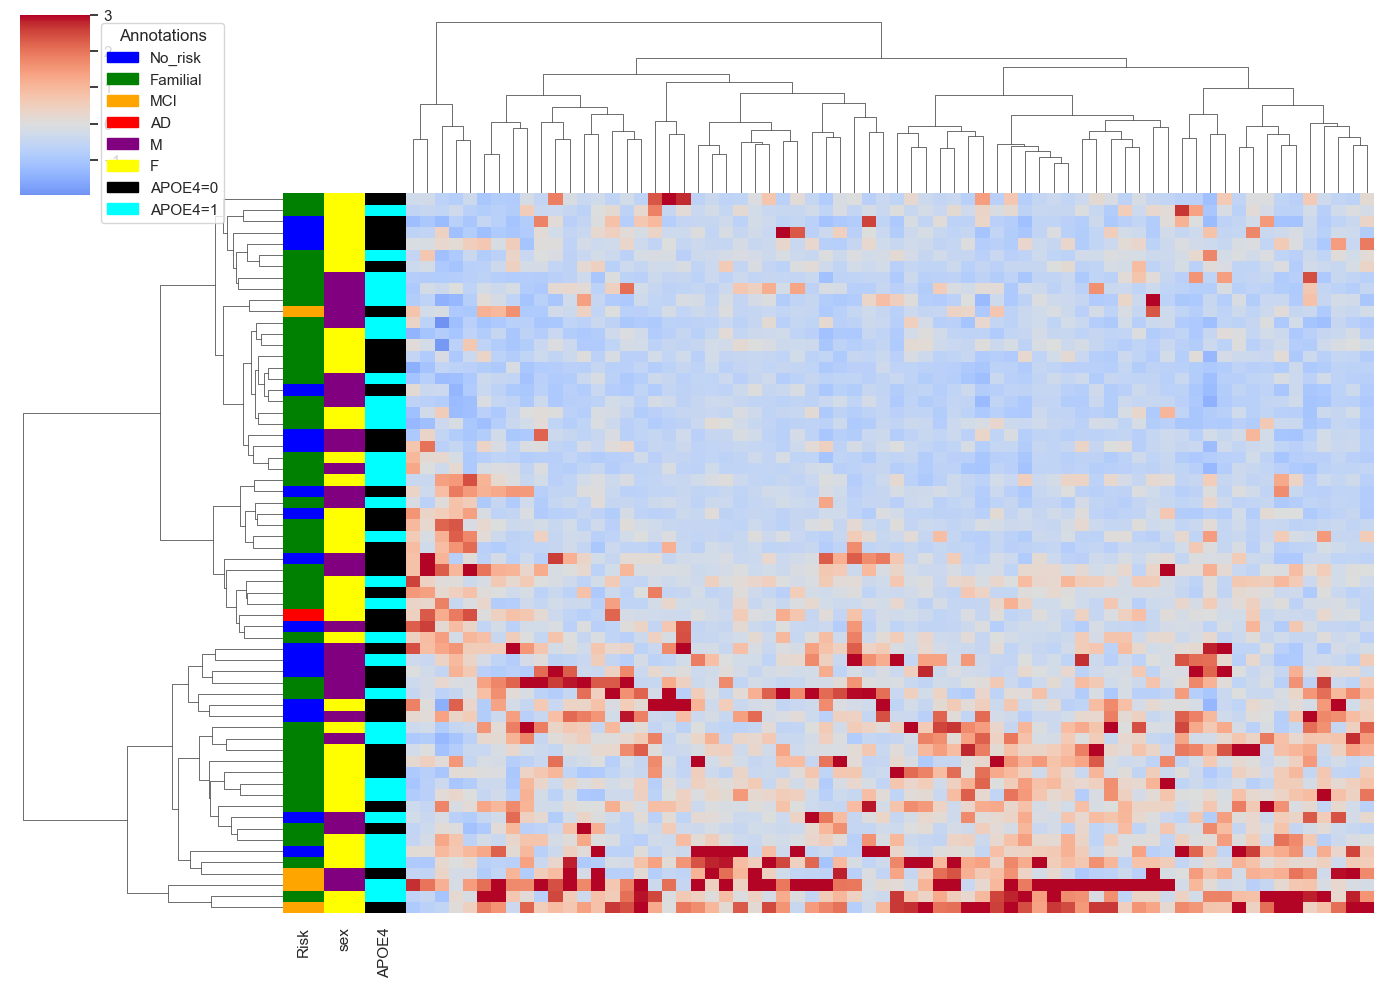

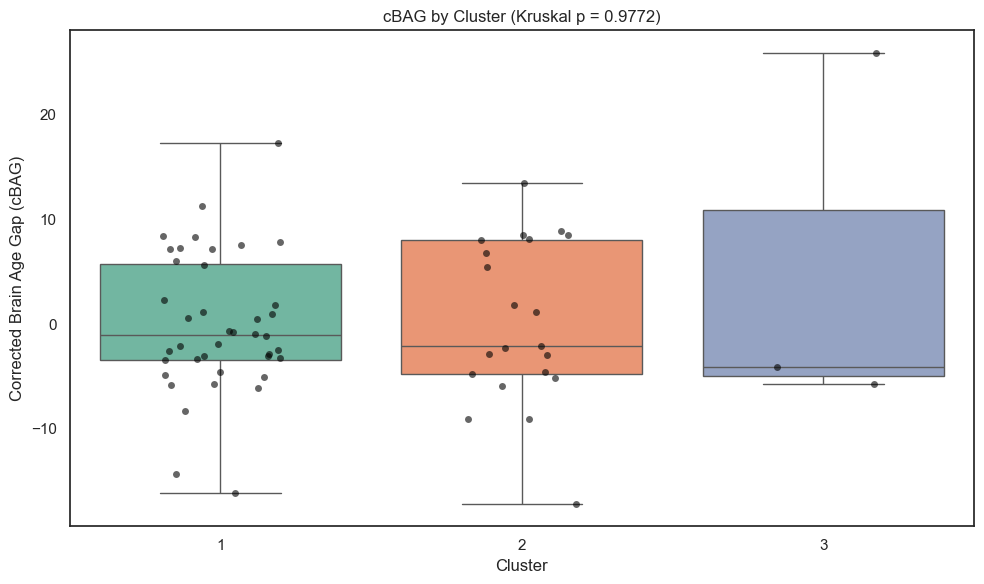

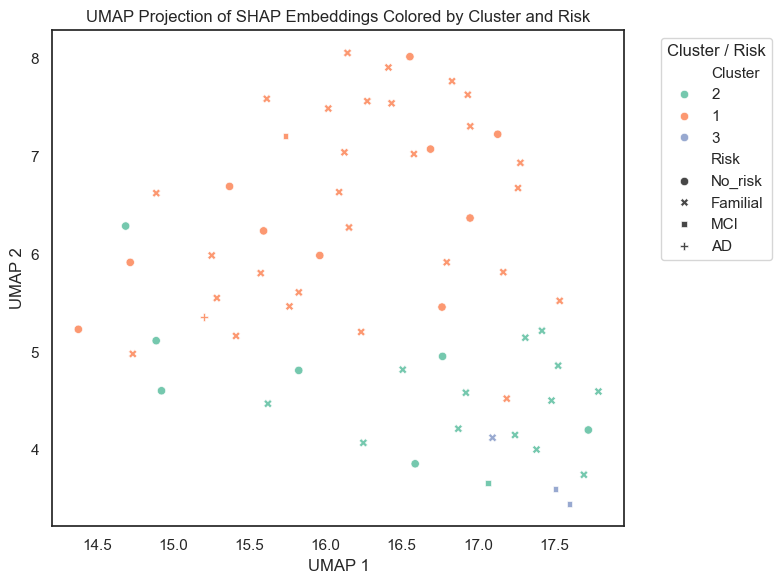

In [13]:
# === Set Number of Clusters Manually ===
n_clusters = 3  # or set to 3 if you prefer
print(f"Manually selected number of clusters: {n_clusters}")



# === Final Clustering ===
linkage_result = linkage(shap_scaled, method='ward')
#cluster_labels = fcluster(linkage_result, t=optimal_clusters, criterion='maxclust')
cluster_labels = fcluster(linkage_result, t=n_clusters, criterion='maxclust')


# === Merge Metadata + Cluster Labels ===
meta_data = merged_df[["Risk", "APOE4", "sex", "bag_corr"]].copy()
meta_data["Risk"] = meta_data["Risk"].fillna("No_risk")
# create a new column 'risk_status' and mark 'No_risk' & 'Familial' as 0, 'MCI' & 'AD' as 1
meta_data["risk_status"] = meta_data["Risk"].map({"No_risk": 0, "Familial": 0, "MCI": 1, "AD": 1})

meta_data["Cluster"] = cluster_labels

# === Save Cluster Assignments and Stats ===
#meta_data.to_csv(os.path.join(save_dir, f"Cluster_Assignments_{optimal_clusters}Clusters_with_cBAG.csv"))
group_stats = meta_data.groupby("Cluster")["bag_corr"].agg(["mean", "std", "count"]).reset_index()
#group_stats.to_csv(os.path.join(save_dir, f"cBAG_Stats_by_{optimal_clusters}Clusters.csv"), index=False)

meta_data.to_csv(os.path.join(save_dir, f"Cluster_Assignments_{n_clusters}Clusters_with_cBAG.csv"))
group_stats = meta_data.groupby("Cluster")["bag_corr"].agg(["mean", "std", "count"]).reset_index()
group_stats.to_csv(os.path.join(save_dir, f"cBAG_Stats_by_{n_clusters}Clusters.csv"), index=False)

# === Kruskal–Wallis Test ===
kruskal_result = kruskal(*[group["bag_corr"].values for name, group in meta_data.groupby("Cluster")])
with open(os.path.join(save_dir, "cBAG_Kruskal_Stats.txt"), "w") as f:
    f.write(f"Kruskal-Wallis H-statistic: {kruskal_result.statistic:.4f}\n")
    f.write(f"p-value: {kruskal_result.pvalue:.4f}\n")

# === Color Annotations ===
risk_colors = {'No_risk': 'blue', 'Familial': 'green', 'MCI': 'orange', 'AD': 'red'}
sex_colors = {'M': 'purple', 'F': 'yellow'}
apoe4_colors = {0: 'black', 1: 'cyan'}

row_colors = pd.concat([
    meta_data["Risk"].map(risk_colors),
    meta_data["sex"].map(sex_colors),
    meta_data["APOE4"].map(apoe4_colors)
], axis=1)
row_colors.columns = ["Risk", "sex", "APOE4"]

# === Clustered Heatmap ===
sns.set(style="white")
cg = sns.clustermap(
    shap_scaled,
    method="ward",
    metric="euclidean",
    row_colors=row_colors,
    cmap="coolwarm",
    center=0,
    figsize=(14, 10),
    col_cluster=True,
    row_cluster=True,
    xticklabels=False,
    yticklabels=False
)

handles = (
    [mpatches.Patch(color=c, label=l) for l, c in risk_colors.items()] +
    [mpatches.Patch(color=c, label=l) for l, c in sex_colors.items()] +
    [mpatches.Patch(color=c, label=f"APOE4={k}") for k, c in apoe4_colors.items()]
)
plt.legend(handles=handles, title="Annotations", bbox_to_anchor=(1.05, 1), loc='upper left')
#cg.savefig(os.path.join(save_dir, f"SHAP_Heatmap_{optimal_clusters}Clusters_APOE4_Sex_Risk.png"), dpi=300, bbox_inches='tight')
cg.savefig(os.path.join(save_dir, f"SHAP_Heatmap_{n_clusters}Clusters_APOE4_Sex_Risk.png"), dpi=300, bbox_inches='tight')

# === Boxplot ===
plt.figure(figsize=(10, 6))
sns.boxplot(data=meta_data, x="Cluster", y="bag_corr", palette="Set2")
sns.stripplot(data=meta_data, x="Cluster", y="bag_corr", color="black", alpha=0.6, jitter=0.2)
plt.title(f"cBAG by Cluster (Kruskal p = {kruskal_result.pvalue:.4f})")
plt.ylabel("Corrected Brain Age Gap (cBAG)")
plt.xlabel("Cluster")
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "cBAG_by_Cluster_Boxplot.png"))

# === UMAP ===
umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='euclidean', random_state=42)
umap_embedding = umap_model.fit_transform(shap_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=umap_embedding[:, 0],
    y=umap_embedding[:, 1],
    hue=meta_data["Cluster"].astype(str),
    style=meta_data["Risk"],
    palette="Set2",
    alpha=0.9
)
plt.title("UMAP Projection of SHAP Embeddings Colored by Cluster and Risk")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend(title="Cluster / Risk", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "UMAP_SHAP_Clusters_ADDECODE.png"))

print("✅ All outputs saved to:", save_dir)


In [14]:

# === Find Top 10 Discriminating Regions by Cluster ===
region_pvals = {}
for region in shap_df.columns:
    groups = [shap_df[region][meta_data["Cluster"] == cluster] for cluster in np.unique(meta_data["Cluster"])]
    stat, p = kruskal(*groups)
    region_pvals[region] = p

# Sort by p-value and select top 10
top_regions = sorted(region_pvals, key=region_pvals.get)[:10]
print("Top 10 discriminating regions by Kruskal–Wallis p-value:", top_regions)


Top 10 discriminating regions by Kruskal–Wallis p-value: ['lh_inferiorparietal', 'lh_supramarginal', 'rh_superiorfrontal', 'rh_bankssts', 'lh_bankssts', 'rh_inferiorparietal', 'lh_superiortemporal', 'rh_supramarginal', 'lh_inferiortemporal', 'lh_rostralmiddlefrontal']


In [15]:

# Save stats to file
top_region_stats_path = os.path.join(save_dir, "Top10_Region_Kruskal_Stats.csv")
pd.DataFrame({
    "Region": top_regions,
    "p-value": [region_pvals[region] for region in top_regions]
}).to_csv(top_region_stats_path, index=False)

# === Plot Boxplots for Top 10 Regions ===
for region in top_regions:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=shap_df.assign(Cluster=meta_data["Cluster"]), x="Cluster", y=region, palette="Set2")
    sns.stripplot(data=shap_df.assign(Cluster=meta_data["Cluster"]), x="Cluster", y=region, color="black", alpha=0.5, jitter=0.2)
    plt.title(f"{region} by Cluster (p = {region_pvals[region]:.4e})")
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, f"Boxplot_{region}_by_Cluster.png"))
    plt.close()

print("📊 Boxplots for top 10 regions saved to:", save_dir)


📊 Boxplots for top 10 regions saved to: bivar_clus_QSM


In [16]:

# === Aggregated Boxplot Panel for Top 10 Regions by Cluster ===
n_cols = 5
n_rows = int(np.ceil(len(top_regions) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 4))
axes = axes.flatten()

for i, region in enumerate(top_regions):
    ax = axes[i]
    sns.boxplot(data=shap_df.assign(Cluster=meta_data["Cluster"]), x="Cluster", y=region, palette="Set2", ax=ax)
    sns.stripplot(data=shap_df.assign(Cluster=meta_data["Cluster"]), x="Cluster", y=region, color="black", alpha=0.5, jitter=0.2, ax=ax)
    pval = region_pvals[region]
    title = f"{region} (p = {pval:.2f})" if not np.isnan(pval) else f"{region} (n/a)"
    ax.set_title(title)
    ax.set_xlabel("Cluster")
    ax.set_ylabel("SHAP Value")

# Remove unused axes if fewer than 10 regions
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Top 10 SHAP Regions by Cluster", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
cluster_panel_path = os.path.join(save_dir, "Top10_Regions_by_Cluster_Panel.png")
plt.savefig(cluster_panel_path, dpi=300)
plt.close()

print("✅ Aggregated cluster panel saved to:", cluster_panel_path)



✅ Aggregated cluster panel saved to: bivar_clus_QSM\Top10_Regions_by_Cluster_Panel.png


In [17]:

from scipy.stats import mannwhitneyu

# Ensure APOE4 status is binary (0 or 1)
apoe4_status = meta_data["APOE4"]

# Perform Mann–Whitney U test for APOE4 effect
apoe4_pvals = {}
for region in top_regions:
    group0 = shap_df.loc[apoe4_status == 0, region]
    group1 = shap_df.loc[apoe4_status == 1, region]
    stat, p = mannwhitneyu(group0, group1, alternative='two-sided')
    apoe4_pvals[region] = p

# Save results to CSV
apoe4_stats_path = os.path.join(save_dir, "Top10_Region_MWU_APOE4.csv")
pd.DataFrame({
    "Region": top_regions,
    "p-value": [apoe4_pvals[region] for region in top_regions]
}).to_csv(apoe4_stats_path, index=False)

# Optional: Plot boxplots by APOE4
for region in top_regions:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=shap_df.assign(APOE4=apoe4_status), x="APOE4", y=region, palette="pastel")
    sns.stripplot(data=shap_df.assign(APOE4=apoe4_status), x="APOE4", y=region, color="black", alpha=0.6, jitter=0.2)
    plt.title(f"{region} by APOE4 (p = {apoe4_pvals[region]:.4e})")
    plt.xticks([0, 1], ["APOE4=0", "APOE4=1"])
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, f"Boxplot_{region}_by_APOE4.png"))
    plt.close()

print("✅ APOE4 comparison done for top 10 regions. Results saved to:", save_dir)


✅ APOE4 comparison done for top 10 regions. Results saved to: bivar_clus_QSM


In [18]:

# === Aggregated Boxplot Panel for APOE4 (All Risk Groups) ===
n_cols = 5
n_rows = int(np.ceil(len(top_regions) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 4))
axes = axes.flatten()

for i, region in enumerate(top_regions):
    ax = axes[i]
    sns.boxplot(data=shap_df.assign(APOE4=apoe4_status), x="APOE4", y=region, palette="pastel", ax=ax)
    sns.stripplot(data=shap_df.assign(APOE4=apoe4_status), x="APOE4", y=region, color="black", alpha=0.6, jitter=0.2, ax=ax)
    pval = apoe4_pvals[region]
    title = f"{region} (p = {pval:.2f})" if not np.isnan(pval) else f"{region} (n/a)"
    ax.set_title(title)
    ax.set_xlabel("APOE4")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["0", "1"])
    ax.set_ylabel("SHAP Value")

# Remove unused axes if top_regions < 10
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Top 10 SHAP Regions by APOE4 Status (All Risk Groups)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
panel_path_all = os.path.join(save_dir, "Top10_Regions_by_APOE4_AllRisk_Panel.png")
plt.savefig(panel_path_all, dpi=300)
plt.close()

print("✅ Aggregated APOE4 panel (all risk groups) saved to:", panel_path_all)




✅ Aggregated APOE4 panel (all risk groups) saved to: bivar_clus_QSM\Top10_Regions_by_APOE4_AllRisk_Panel.png


In [19]:
from statsmodels.stats.multitest import multipletests
from scipy.stats import mannwhitneyu

# Ensure risk status is binary (0 or 1)
risk_status = meta_data["risk_status"]

def cliffs_delta(a, b):
    n, m = len(a), len(b)
    more = sum(x > y for x in a for y in b)
    less = sum(x < y for x in a for y in b)
    return (more - less) / (n * m)

# Perform Mann–Whitney U test for risk effect
risk_pvals = {}
mw_results = []
for region in top_regions:
    group0 = shap_df.loc[risk_status == 0, region]
    group1 = shap_df.loc[risk_status == 1, region]
    stat, p = mannwhitneyu(group0, group1, alternative='two-sided')
    delta = cliffs_delta(group0, group1)
    risk_pvals[region] = p
    mw_results.append((region, stat, p, delta))

# Save results to CSV
risk_stats_path = os.path.join(save_dir, "Top10_Region_MWU_Risk.csv")
pd.DataFrame({
    "Region": top_regions,
    "p-value": [risk_pvals[region] for region in top_regions]
}).to_csv(risk_stats_path, index=False)

# FDR correction
mw_pvals = [risk_pvals[region] for region in top_regions]
_, mw_pvals_fdr, _, _ = multipletests(mw_pvals, method='fdr_bh')

mw_df = pd.DataFrame(mw_results, columns=["Region", "U", "p-value", "cliffs_delta"])
mw_df["FDR_p"] = mw_pvals_fdr
mw_df = mw_df.sort_values("p-value")
mw_df.to_csv(os.path.join(save_dir, "Top10_Region_MWU_Risk_with_Delta_FDR.csv"), index=False)

# Optional: Plot boxplots by risk status
for region in top_regions:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=shap_df.assign(risk_status=risk_status), x="risk_status", y=region, palette="pastel")
    sns.stripplot(data=shap_df.assign(risk_status=risk_status), x="risk_status", y=region, color="black", alpha=0.6, jitter=0.2)
    plt.title(f"{region} by Risk Status (p = {risk_pvals[region]:.4e})")
    plt.xticks([0, 1], ["No Risk/Familial", "MCI/AD"])
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, f"Boxplot_{region}_by_Risk_Status.png"))
    plt.close()

print("✅ Risk status comparison done for top 10 regions. Results saved to:", save_dir)


✅ Risk status comparison done for top 10 regions. Results saved to: bivar_clus_QSM


In [20]:
# === Aggregated Boxplot Panel for Risk Status ===
n_cols = 5
n_rows = int(np.ceil(len(top_regions) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 4))
axes = axes.flatten()

for i, region in enumerate(top_regions):
    ax = axes[i]
    sns.boxplot(data=shap_df.assign(risk_status=risk_status), x="risk_status", y=region, palette="pastel", ax=ax)
    sns.stripplot(data=shap_df.assign(risk_status=risk_status), x="risk_status", y=region, color="black", alpha=0.6, jitter=0.2, ax=ax)
    pval = risk_pvals[region]
    title = f"{region} (p = {pval:.2f})" if not np.isnan(pval) else f"{region} (n/a)"
    ax.set_title(title)
    ax.set_xlabel("Risk")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No Risk/Familial", "MCI/AD"])
    ax.set_ylabel("SHAP Value")

# Remove unused axes if top_regions < 10
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Top 10 SHAP Regions by Risk Status", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
panel_path_all = os.path.join(save_dir, "Top10_Regions_by_Risk_Status_Panel.png")
plt.savefig(panel_path_all, dpi=300)
plt.close()

print("✅ Aggregated Risk Status panel saved to:", panel_path_all)


✅ Aggregated Risk Status panel saved to: bivar_clus_QSM\Top10_Regions_by_Risk_Status_Panel.png


In [27]:

import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu

# === Update Risk labels in metadata ===
meta_data["Risk"] = meta_data["Risk"].fillna("No_risk")

# === Filter metadata to No_risk or Familial only ===
filtered_meta = meta_data[meta_data["Risk"].isin(["No_risk", "Familial"])]
filtered_shap = shap_df.loc[filtered_meta.index]
filtered_apoe4 = filtered_meta["APOE4"]

# === Mann–Whitney U tests for top 10 regions ===
filtered_pvals = {}
for region in top_regions:
    group0 = filtered_shap.loc[filtered_apoe4 == 0, region]
    group1 = filtered_shap.loc[filtered_apoe4 == 1, region]
    if len(group0) > 0 and len(group1) > 0:
        stat, p = mannwhitneyu(group0, group1, alternative='two-sided')
        filtered_pvals[region] = p
    else:
        filtered_pvals[region] = np.nan  # in case group missing

# === Save p-values to CSV ===
filtered_stats_path = os.path.join(save_dir, "Top10_Region_MWU_APOE4_LowRisk.csv")
pd.DataFrame({
    "Region": top_regions,
    "p-value": [f"{filtered_pvals[region]:.3f}" if not np.isnan(filtered_pvals[region]) else "NA" for region in top_regions]
}).to_csv(filtered_stats_path, index=False)

# === Aggregated Boxplot Panel for Top 10 Regions ===
n_cols = 5
n_rows = int(np.ceil(len(top_regions) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 4))
axes = axes.flatten()

for i, region in enumerate(top_regions):
    ax = axes[i]
    sns.boxplot(data=filtered_shap.assign(APOE4=filtered_apoe4), x="APOE4", y=region, palette="pastel", ax=ax)
    sns.stripplot(data=filtered_shap.assign(APOE4=filtered_apoe4), x="APOE4", y=region, color="black", alpha=0.6, jitter=0.2, ax=ax)
    pval = filtered_pvals[region]
    title = f"{region} (p = {pval:.2f})" if not np.isnan(pval) else f"{region} (n/a)"
    ax.set_title(title)
    ax.set_xlabel("APOE4")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["0", "1"])
    ax.set_ylabel("SHAP Value")

# Remove unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Top 10 SHAP Regions by APOE4 Status (No_risk / Familial Only)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
panel_path = os.path.join(save_dir, "Top10_Regions_by_APOE4_LowRisk_Panel.png")
plt.savefig(panel_path, dpi=300)
plt.close()

print("✅ APOE4 boxplot panel and stats saved to:", save_dir)


✅ APOE4 boxplot panel and stats saved to: bivar_clus_QSM


In [28]:

from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns

# === Create Contingency Table: Cluster vs Risk ===
risk_cluster_table = pd.crosstab(meta_data["Cluster"], meta_data["Risk"])
risk_cluster_table.to_csv(os.path.join(save_dir, "Contingency_Risk_by_Cluster.csv"))

# === Chi-squared Test ===
chi2, pval, dof, expected = chi2_contingency(risk_cluster_table)

# === Save Test Results ===
with open(os.path.join(save_dir, "Chi2_Risk_by_Cluster.txt"), "w") as f:
    f.write("Chi-squared test for Risk ~ Cluster\n")
    f.write(f"Chi2 = {chi2:.4f}, df = {dof}, p = {pval:.4f}\n")
    f.write("\nExpected frequencies:\n")
    pd.DataFrame(expected, index=risk_cluster_table.index, columns=risk_cluster_table.columns).to_csv(f)

print(f"✅ Chi-squared test completed. p = {pval:.4f}")


✅ Chi-squared test completed. p = 0.0019


In [29]:

# === Aggregated Panel Plot: Risk Composition per Cluster ===
cluster_risk_props = (
    meta_data.groupby(["Cluster", "Risk"]).size()
    .div(meta_data.groupby("Cluster").size(), level=0)
    .unstack(fill_value=0)
)

# Plot
# Ensure consistent color order and handle missing risk categories gracefully
desired_order = list(risk_colors.keys())
cluster_risk_props = cluster_risk_props.reindex(columns=desired_order, fill_value=0)

ax = cluster_risk_props.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    color=[risk_colors[r] for r in cluster_risk_props.columns]
)

plt.title(f"Risk Composition by Cluster (Chi² p = {pval:.2f})")
plt.ylabel("Proportion")
plt.xlabel("Cluster")
plt.legend(title="Risk", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "StackedBar_Risk_by_Cluster.png"))
plt.close()

print("📊 Aggregated barplot of Risk by Cluster saved.")


📊 Aggregated barplot of Risk by Cluster saved.


In [30]:

# === APOE4 Composition by Cluster ===
apoe_table = pd.crosstab(meta_data["Cluster"], meta_data["APOE4"])
apoe_table.to_csv(os.path.join(save_dir, "Contingency_APOE4_by_Cluster.csv"))

chi2, pval, dof, expected = chi2_contingency(apoe_table)
with open(os.path.join(save_dir, "Chi2_APOE4_by_Cluster.txt"), "w") as f:
    f.write("Chi-squared test for APOE4 ~ Cluster\n")
    f.write(f"Chi2 = {chi2:.4f}, df = {dof}, p = {pval:.4f}\n")

# Plot
apoe_props = (
    meta_data.groupby(["Cluster", "APOE4"]).size()
    .div(meta_data.groupby("Cluster").size(), level=0)
    .unstack(fill_value=0)
)
ax = apoe_props.plot(
    kind="bar", stacked=True, figsize=(8, 5), color=["gray", "cyan"]
)
plt.title(f"APOE4 Composition by Cluster (Chi² p = {pval:.2f})")
plt.ylabel("Proportion")
plt.xlabel("Cluster")
plt.legend(title="APOE4", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "StackedBar_APOE4_by_Cluster.png"))
plt.close()

# === Sex Composition by Cluster ===
sex_table = pd.crosstab(meta_data["Cluster"], meta_data["sex"])
sex_table.to_csv(os.path.join(save_dir, "Contingency_Sex_by_Cluster.csv"))

chi2, pval, dof, expected = chi2_contingency(sex_table)
with open(os.path.join(save_dir, "Chi2_Sex_by_Cluster.txt"), "w") as f:
    f.write("Chi-squared test for Sex ~ Cluster\n")
    f.write(f"Chi2 = {chi2:.4f}, df = {dof}, p = {pval:.4f}\n")

# Plot
sex_props = (
    meta_data.groupby(["Cluster", "sex"]).size()
    .div(meta_data.groupby("Cluster").size(), level=0)
    .unstack(fill_value=0)
)
ax = sex_props.plot(
    kind="bar", stacked=True, figsize=(8, 5), color=["purple", "gold"]
)
plt.title(f"Sex Composition by Cluster (Chi² p = {pval:.2f})")
plt.ylabel("Proportion")
plt.xlabel("Cluster")
plt.legend(title="Sex", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "StackedBar_Sex_by_Cluster.png"))
plt.close()

cluster_summary = meta_data.groupby("Cluster").agg({
    "bag_corr": ["mean", "std"],
    "APOE4": "mean",
    "sex": lambda x: (x == "F").mean(),
    "Risk": lambda x: x.value_counts().to_dict()
})
cluster_summary.to_csv(os.path.join(save_dir, "Cluster_Descriptive_Stats.csv"))


In [31]:

from scipy.stats import iqr

# === Export sample size, median, and IQR per region and cluster ===
output_lines = []
output_lines.append("📊 SHAP Region Summary Statistics by Cluster\n")
output_lines.append(f"Top regions based on Kruskal–Wallis p-values: {', '.join(top_regions)}\n")
output_lines.append("============================================\n")

for cluster in sorted(meta_data["Cluster"].unique()):
    output_lines.append(f"\n🧩 Cluster {cluster} (n = {np.sum(meta_data['Cluster'] == cluster)})")
    output_lines.append("Region\tMedian\tIQR")
    for region in top_regions:
        values = shap_df.loc[meta_data["Cluster"] == cluster, region]
        med = np.median(values)
        iqr_val = iqr(values)
        output_lines.append(f"{region}\t{med:.3f}\t{iqr_val:.3f}")

# Save to text file
summary_txt_path = os.path.join(save_dir, f"TopRegions_Median_IQR_by_Cluster.txt")
with open(summary_txt_path, "w") as f:
    for line in output_lines:
        f.write(line + "\n")

print(f"✅ Summary statistics exported to: {summary_txt_path}")



✅ Summary statistics exported to: bivar_clus_QSM\TopRegions_Median_IQR_by_Cluster.txt


In [32]:

from statsmodels.stats.multitest import multipletests

# === η² Effect Size for Kruskal–Wallis ===
def eta_squared_kruskal(H, groups, N):
    return (H - len(groups) + 1) / (N - len(groups))

kruskal_results = []
for region in shap_df.columns:
    data_groups = [shap_df[region][meta_data["Cluster"] == g] for g in np.unique(meta_data["Cluster"])]
    H, p = kruskal(*data_groups)
    eta2 = eta_squared_kruskal(H, data_groups, len(shap_df))
    kruskal_results.append((region, H, p, eta2))

# FDR correction
p_vals = [p for _, _, p, _ in kruskal_results]
_, pvals_fdr, _, _ = multipletests(p_vals, method='fdr_bh')

kruskal_df = pd.DataFrame(kruskal_results, columns=["Region", "H", "p-value", "eta_squared"])
kruskal_df["FDR_p"] = pvals_fdr
kruskal_df = kruskal_df.sort_values("p-value")
kruskal_df.to_csv(os.path.join(save_dir, "Top10_Region_Kruskal_Stats_with_Eta2_FDR.csv"), index=False)

# === Cliff's Delta for APOE4 Effect ===
def cliffs_delta(a, b):
    n, m = len(a), len(b)
    more = sum(x > y for x in a for y in b)
    less = sum(x < y for x in a for y in b)
    return (more - less) / (n * m)

mw_results = []
for region in shap_df.columns:
    group0 = shap_df.loc[apoe4_status == 0, region]
    group1 = shap_df.loc[apoe4_status == 1, region]
    stat, p = mannwhitneyu(group0, group1, alternative="two-sided")
    delta = cliffs_delta(group0, group1)
    mw_results.append((region, stat, p, delta))

# FDR correction
mw_pvals = [p for _, _, p, _ in mw_results]
_, mw_pvals_fdr, _, _ = multipletests(mw_pvals, method='fdr_bh')

mw_df = pd.DataFrame(mw_results, columns=["Region", "U", "p-value", "cliffs_delta"])
mw_df["FDR_p"] = mw_pvals_fdr
mw_df = mw_df.sort_values("p-value")
mw_df.to_csv(os.path.join(save_dir, "Top10_Region_MWU_APOE4_with_Delta_FDR.csv"), index=False)